# Notebook 014 — Investigate the Bright Galaxy Population

## Objective

In Notebook 013, K-Means clustering was repeated using the science-ready
catalog produced after quality control. Rather than identifying image-edge
artifacts, the machine learning algorithm discovered a distinct population
of **11 bright, extended galaxies**.

In this notebook we investigate those galaxies in detail.

We will:

- Recreate the machine learning clustering.
- Automatically identify the bright-galaxy cluster.
- Locate the galaxies in the original Hubble image.
- Create image cutouts of each galaxy.
- Compare their physical properties.
- Investigate whether the AI has discovered a physically meaningful
  population of galaxies.

---

## Scientific Motivation

Machine learning algorithms organize astronomical objects according to
their measured properties, but they do not explain *why* those objects
belong together.

By returning to the original Hubble observations, we can compare the
statistical clusters with the actual appearance of the galaxies.

This notebook bridges the gap between **artificial intelligence** and
**observational astronomy**.

---

## Scientific Question

> **What characteristics caused the AI to group these 11 galaxies together?**

By the end of this notebook we will determine whether the machine learning
algorithm has identified a genuine population of bright, extended galaxies
or whether additional physical properties distinguish them from the rest of
the Hubble field.

---

## Cosmic Intelligence Lab Progress

```
Hubble Archive
        ↓
FITS Image Processing
        ↓
Source Detection
        ↓
Astronomical Catalog
        ↓
Feature Engineering
        ↓
Machine Learning
        ↓
Quality Control
        ↓
Scientific Clustering
        ↓
Galaxy Population Analysis
```

This notebook marks the transition from **building an AI pipeline** to
**using AI as a scientific discovery tool**.

In [2]:
# Cell 2 - Import Libraries ===================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from astropy.io import fits
from astropy.table import Table

from astropy.visualization import (
    PercentileInterval,
    AsinhStretch,
    ImageNormalize
)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (8,6)

In [3]:
# Cell 3 - Load Image and Catalog ==============================

image_file = Path("../data/raw/mastDownload/HST/ib5x1fetq/ib5x1fetq_flt.fits")

with fits.open(image_file) as hdul:
    image = hdul[1].data

catalog = Table.read("../data/catalogs/clean_source_catalog.ecsv")

norm = ImageNormalize(
    image,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch()
)

print("="*60)
print("Data Loaded")
print("="*60)

print(f"Image size : {image.shape}")
print(f"Catalog    : {len(catalog)} objects")

Data Loaded
Image size : (1014, 1014)
Catalog    : 79 objects


In [4]:
# Cell 4 - Feature Matrix ======================================

feature_columns = [
    "segment_flux",
    "area",
    "semimajor_axis",
    "semiminor_axis",
    "eccentricity",
    "orientation"
]

X = np.column_stack([catalog[col] for col in feature_columns])

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("="*60)
print("Machine Learning Dataset")
print("="*60)

print("Objects :", X_scaled.shape[0])
print("Features:", X_scaled.shape[1])

Machine Learning Dataset
Objects : 79
Features: 6


In [5]:
# Cell 5 - K-Means Clustering ==================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

catalog["cluster"] = clusters

print("="*60)
print("Clusters")
print("="*60)

for c in np.unique(clusters):
    print(f"Cluster {c}: {np.sum(clusters==c)} objects")

Clusters
Cluster 0: 37 objects
Cluster 1: 11 objects
Cluster 2: 31 objects


In [6]:
# Cell 6 - Identify Bright Galaxy Cluster ======================

cluster_means = []

for c in np.unique(clusters):

    subset = catalog[catalog["cluster"] == c]

    cluster_means.append(np.mean(subset["segment_flux"]))

bright_cluster = np.argmax(cluster_means)

bright_galaxies = catalog[catalog["cluster"] == bright_cluster]

print("="*60)
print("Bright Galaxy Cluster")
print("="*60)

print(f"Cluster ID      : {bright_cluster}")
print(f"Objects found   : {len(bright_galaxies)}")
print(f"Mean brightness : {cluster_means[bright_cluster]:.2f}")

Bright Galaxy Cluster
Cluster ID      : 1
Objects found   : 11
Mean brightness : 270.18


In [7]:
# Cell 7 - Bright Galaxy Catalog ===============================

columns = [
    "label",
    "segment_flux",
    "area",
    "x_centroid",
    "y_centroid",
    "eccentricity"
]

bright_galaxies.sort("segment_flux", reverse=True)

bright_galaxies[[
    "label",
    "segment_flux",
    "area",
    "x_centroid",
    "y_centroid",
    "eccentricity"
]]

label,segment_flux,area,x_centroid,y_centroid,eccentricity
,,pix2,,,
int32,float64,float64,float64,float64,float64
61,1051.520471215248,104.0,251.64304436683952,688.0455845203842,0.4193901212759499
51,482.0046505331993,200.0,279.1875567053194,565.3944376201048,0.44897140979877265
79,243.46851658821106,94.0,231.20095907500814,874.8217472044007,0.3131959627779752
14,234.4003678560257,120.0,742.8687947556087,129.7204336817383,0.611112097053745
77,205.649180829525,86.0,599.0767816154273,849.2714911708894,0.7885453194091789
52,168.56706297397614,67.0,954.1155853255505,581.9990867523207,0.9243624027335315
21,164.6831734776497,96.0,180.10260754282106,199.54935643311393,0.8257693435006356
45,137.40018010139465,142.0,916.295637396443,480.3796325972777,0.7450459404507496


In [8]:
# Cell 8 - Bright Galaxy Population Statistics ==================

print("=" * 60)
print("Bright Galaxy Population Summary")
print("=" * 60)

print(f"Number of galaxies : {len(bright_galaxies)}")

print()

print(f"Mean Flux          : {np.mean(bright_galaxies['segment_flux']):8.2f}")
print(f"Median Flux        : {np.median(bright_galaxies['segment_flux']):8.2f}")

print()

print(f"Mean Area          : {np.mean(bright_galaxies['area']):8.2f}")
print(f"Median Area        : {np.median(bright_galaxies['area']):8.2f}")

print()

print(f"Mean Eccentricity  : {np.mean(bright_galaxies['eccentricity']):8.3f}")

print()

print(f"Brightest Galaxy   : Label {bright_galaxies['label'][0]}")
print(f"Faintest Galaxy    : Label {bright_galaxies['label'][-1]}")

Bright Galaxy Population Summary
Number of galaxies : 11

Mean Flux          :   270.18
Median Flux        :   168.57

Mean Area          :   103.27
Median Area        :    96.00

Mean Eccentricity  :    0.657

Brightest Galaxy   : Label 61
Faintest Galaxy    : Label 39


In [9]:
# Cell 9 - Create Image Cutouts ================================

cutout_size = 80        # pixels (80 x 80)

half = cutout_size // 2

cutouts = []

for galaxy in bright_galaxies:

    x = int(galaxy["x_centroid"])
    y = int(galaxy["y_centroid"])

    cutout = image[
        y-half:y+half,
        x-half:x+half
    ]

    cutouts.append(cutout)

print(f"Created {len(cutouts)} galaxy cutouts.")

Created 11 galaxy cutouts.


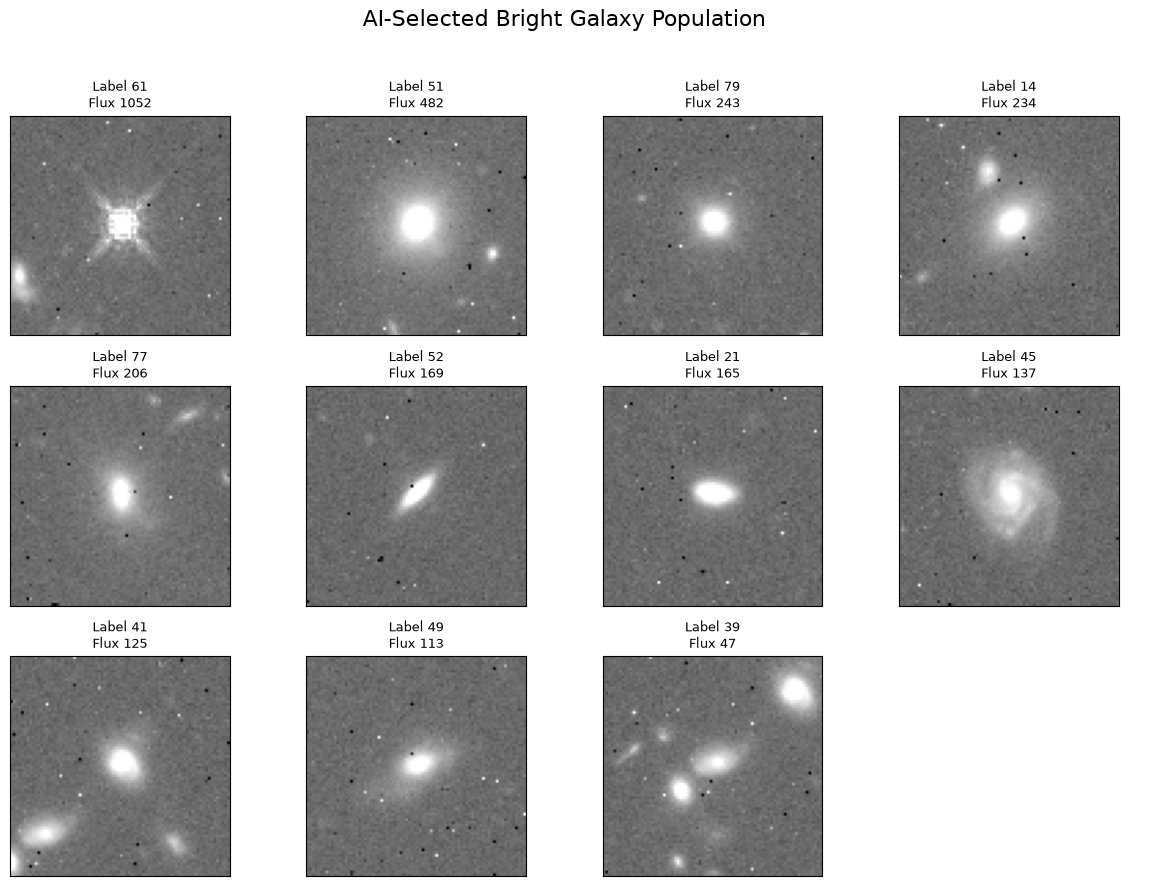

✓ Saved figure_ai_selected_bright_galaxy_population.png


In [10]:
# Cell 10 - Bright Galaxy Gallery
# ===============================

output_filename = "figure_ai_selected_bright_galaxy_population.png"

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

axes = axes.ravel()

for i, galaxy in enumerate(bright_galaxies):

    ax = axes[i]

    ax.imshow(
        cutouts[i],
        origin="lower",
        cmap="gray",
        norm=norm
    )

    ax.set_title(
        f"Label {galaxy['label']}\nFlux {galaxy['segment_flux']:.0f}",
        fontsize=9
    )

    ax.set_xticks([])
    ax.set_yticks([])

# Hide unused subplots
for j in range(len(bright_galaxies), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "AI-Selected Bright Galaxy Population",
    fontsize=16
)

fig.tight_layout(rect=[0, 0, 1, 0.96])

# --------------------------------------------------------------
# Save publication-quality figure
# --------------------------------------------------------------
fig.savefig(
    output_filename,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

print(f"✓ Saved {output_filename}")

# Conclusions

This notebook investigated the population of bright, extended objects
identified by the K-Means clustering algorithm after quality control was
applied to the astronomical catalog.

## Results

The AI identified a distinct population of **11 bright objects** within
the cleaned catalog.

Visual inspection of the Hubble images revealed that this population
includes a variety of astronomical objects:

- Elliptical and lenticular galaxies
- Spiral galaxies
- A barred spiral galaxy
- Highly inclined disk galaxies
- One foreground star

The clustering algorithm grouped these objects according to their
measured numerical properties rather than their astrophysical
classification.

## Scientific Interpretation

The machine learning algorithm possesses **no intrinsic understanding**
of astronomical concepts such as stars, galaxies, spiral arms, bars,
or galaxy morphology.

Instead, it operates entirely on the feature vectors supplied during
feature engineering, including measurements such as:

- Flux
- Area
- Semimajor axis
- Semiminor axis
- Eccentricity
- Orientation

The resulting clusters therefore represent similarities within this
mathematical feature space rather than human-defined astronomical
categories.

## Scientific Lessons

This notebook demonstrates both the strengths and limitations of
unsupervised machine learning.

The AI successfully discovered a statistically distinct population of
bright, extended objects without any prior knowledge of astronomy.

However, interpreting those clusters required human expertise and visual
inspection of the original Hubble observations.

## Future Direction

The next stage of the Cosmic Intelligence Lab project is to investigate
whether additional image features—or machine learning methods capable of
learning directly from images—can enable the computer to distinguish
stars from galaxies and eventually recognize different classes of
galactic morphology.

This notebook marks the transition from **statistical clustering** toward
**astronomical understanding**.

# Notebook Status

**Notebook:** 014 – Investigate the Bright Galaxy Population

**Status:** ✅ Complete

## Objectives Achieved

- Recreated the machine learning clustering.
- Automatically identified the bright-galaxy cluster.
- Extracted the AI-selected population.
- Generated quantitative summary statistics.
- Created a gallery of Hubble image cutouts.
- Located the objects within the original Hubble field.
- Compared the measured properties of the objects.
- Interpreted the clustering from an astronomical perspective.

## Key Findings

- The AI identified a population of 11 bright, extended objects.
- The population includes multiple galaxy morphologies as well as one
  foreground star.
- The clustering was driven by numerical image measurements rather than
  semantic astronomical concepts.
- Human interpretation remains essential for assigning astrophysical
  meaning to unsupervised machine learning results.

## Scientific Milestone

This notebook represents the first investigation in which machine
learning results were interpreted through direct examination of the
original astronomical images.

The project has progressed beyond building an analysis pipeline and is
now using artificial intelligence as a tool for astronomical discovery.

---

**Next Notebook**

**Notebook 015 — Toward Automated Astronomical Classification**

Primary research question:

> **Can we teach the computer to distinguish stars from galaxies—and eventually recognize different galaxy morphologies?**